In [26]:
import copy
import pdb
import sys
from tqdm import tqdm
from pathos.pools import ProcessPool
sys.path.append('/Users/leonardo.tessarolo/git/bayesian_bss/')

import numpy as np
import math
import pandas as pd
from scipy.special import gamma
import scipy.stats as st

import jax
import jax.numpy as jnp
from jax.scipy.stats import t as jax_t
jax.config.update("jax_enable_x64", True)

from numpyro.infer import MCMC, BarkerMH
from numpyro.diagnostics import gelman_rubin, autocorrelation, autocovariance, effective_sample_size
# from numpyro.diagnostics import split_gelman_rubin as gelman_rubin

from matplotlib import pyplot as plt

from src import MMSEMetropolisHastingsEstimator

np.random.seed(100)

# 1. Definir classes

In [2]:
class PosteriorUtilities:
    @staticmethod
    def get_log_posterior_fn(
        source_pdf_fn,
        prior_pdf_fn,
        use_jax=False
    ):
        """
            This method returns a method for calculating log-posterior inside MCMC.

            The `use_jax` toggle selects the backend:
              - use_jax=False -> original standard-Python / NumPy implementation
                (scalar source_pdf_fn evaluated element-by-element).
              - use_jax=True  -> jax.numpy implementation that is differentiable and
                jit-traceable. It expects `source_pdf_fn` and `prior_pdf_fn` to have
                been built with their own use_jax=True (i.e. elementwise, jnp-based).
        """
        if not use_jax:
            def __log_posterior_fn(
                x,
                B,
                source_pdf_fn,
                prior_pdf_fn
            ):
                NOBS=x.shape[-1]
                # Cálculo de posteriori para registros
                priori = prior_pdf_fn(B)
                if priori > 0:
                    posteriori = NOBS*np.log(np.abs(np.linalg.det(B))) + np.log(priori)
                    y=B@x
                    iterator = np.ndindex(x.shape)
                    posteriori += np.sum(np.log(
                        np.array([
                            source_pdf_fn(y[i,j]) for i,j in iterator
                        ])
                    ))
                elif priori == 0:
                    posteriori = -np.inf
                else:
                    raise ValueError('Prior value must be non-negative.')
                    # posteriori += np.log(prior_pdf_fn(B))
                return posteriori

            return lambda x, B: __log_posterior_fn(
                x=x,
                B=B,
                source_pdf_fn=source_pdf_fn,
                prior_pdf_fn=prior_pdf_fn
            )
        else:
            def __log_posterior_fn(
                x,
                B,
                source_pdf_fn,
                prior_pdf_fn
            ):
                x = jnp.asarray(x)
                B = jnp.asarray(B)

                NOBS=x.shape[-1]
                # Cálculo de posteriori para registros
                priori = prior_pdf_fn(B)
                # Termo de verossimilhança. slogdet dá log|det(B)| de forma estável,
                # evitando o np.abs(np.linalg.det(B)) que sofre underflow/overflow.
                sign, logabsdet = jnp.linalg.slogdet(B)
                # y = B@x
                y=jnp.matmul(B,x)
                # Chamada VETORIZADA: source_pdf_fn é elementwise (jnp), então
                # avaliamos a densidade de fonte em toda a matriz de uma só vez.
                log_source = jnp.sum(jnp.log(source_pdf_fn(y)))
                log_lik = NOBS*logabsdet + log_source
                # Log-priori segura: o duplo `where` impede gradientes NaN vindos de
                # log(0), pois o JAX avalia os dois ramos antes de selecionar.
                safe_priori = jnp.where(priori > 0, priori, 1.0)
                log_prior = jnp.where(priori > 0, jnp.log(safe_priori), -jnp.inf)
                posteriori = jnp.where(priori > 0, log_lik + log_prior, -jnp.inf)
                return posteriori

            return lambda x, B: __log_posterior_fn(
                x=x,
                B=B,
                source_pdf_fn=source_pdf_fn,
                prior_pdf_fn=prior_pdf_fn
            )


In [3]:
class LogisticSource:
    def __init__(
        self,
        mu,
        sigma,
        use_jax=False
    ):
        # Save attributes
        self.mu=mu
        self.sigma=sigma
        # Backend toggle. Standard-Python path keeps the original SCALAR pdf
        # (evaluated element-by-element). JAX path returns an ELEMENTWISE pdf that
        # can be applied to the whole (nsources, nobs) array at once and is
        # differentiable / jit-traceable.
        self.use_jax=use_jax

    def get(
        self
    ):
        if not self.use_jax:
            def __logistic_distribution(
                x
            ):
                """
                    This method takes SCALAR value x and return SCALAR source pdf evaluated at x.
                """
                arg = math.exp(
                    -(x-self.mu)/self.sigma
                )
                return arg/(
                    self.sigma*((1+arg)*(1+arg))
                )
            return lambda x: __logistic_distribution(x=x)
        else:
            def __logistic_distribution(
                x
            ):
                """
                    This method takes an ARRAY x and returns the ELEMENTWISE source pdf (jax.numpy).
                """
                arg = jnp.exp(
                    -(x-self.mu)/self.sigma
                )
                return arg/(
                    self.sigma*((1+arg)*(1+arg))
                )
            return lambda x: __logistic_distribution(x=x)

    def get_derivative(
        self
    ):
        # NOTE: not needed when use_jax=True (autodiff handles it). Kept for the
        # standard-Python path.
        def __logistic_distribution_derivative(
            x
        ):
            """
                This method takes SCALAR value x and return SCALAR source pdf derivative evaluated at x.
            """
            # Calculate repeated subexpressions
            arg1 = math.exp(
                -(x-self.mu)/self.sigma
            )
            arg2 = 1 + arg1
            return (
                (2*(arg1*arg1)*arg2) - (arg1*arg2*arg2)
            )/(
                (self.sigma*self.sigma)*pow(arg2, 4)
            )
        return lambda x: __logistic_distribution_derivative(x=x)

    def get_cumulative(
        self
    ):
        if not self.use_jax:
            def __logistic_distribution_cumulative(
                x
            ):
                """
                    This method takes SCALAR value x and return SCALAR source cdf evaluated at x.
                """
                return 1/(
                    1 + math.exp(-(x-self.mu)/self.sigma)
                )
            return lambda x: __logistic_distribution_cumulative(x=x)
        else:
            def __logistic_distribution_cumulative(
                x
            ):
                """
                    This method takes an ARRAY x and returns the ELEMENTWISE source cdf (jax.numpy).
                """
                return 1/(
                    1 + jnp.exp(-(x-self.mu)/self.sigma)
                )
            return lambda x: __logistic_distribution_cumulative(x=x)

    def get_realization(
        self,
        nsources,
        nobs,
        seed=None
    ):
        if seed is not None:
            np.random.seed(seed)
        return np.random.logistic(
            loc=self.mu,
            scale=self.sigma,
            size=(nsources, nobs)
        )


class StandardLogisticSource:
    def __init__(
        self,
        use_jax=False
    ):
        self.use_jax=use_jax

    def get(
        self
    ):
        if not self.use_jax:
            def __logistic_distribution(
                x
            ):
                """
                    This method takes SCALAR value x and return SCALAR source pdf evaluated at x.
                """
                arg = math.exp(-x)
                return arg/((1+arg)*(1+arg))
            return lambda x: __logistic_distribution(x=x)
        else:
            def __logistic_distribution(
                x
            ):
                """
                    This method takes an ARRAY x and returns the ELEMENTWISE source pdf (jax.numpy).
                """
                arg = jnp.exp(-x)
                return arg/((1+arg)*(1+arg))
            return lambda x: __logistic_distribution(x=x)

    def get_derivative(
        self
    ):
        # NOTE: not needed when use_jax=True (autodiff handles it).
        def __logistic_distribution_derivative(
            x
        ):
            """
                This method takes SCALAR value x and return SCALAR source pdf derivative evaluated at x.
            """
            arg = 1+math.exp(-x)
            return (
                2*math.exp(-2*x)*(arg) - math.exp(-x)*(arg*arg)
            )/pow(arg, 4)
        return lambda x: __logistic_distribution_derivative(x=x)

    def get_cumulative(
        self
    ):
        if not self.use_jax:
            def __logistic_distribution_cumulative(
                x
            ):
                """
                    This method takes SCALAR value x and return SCALAR source cdf evaluated at x.
                """
                return 1/(1 + math.exp(-x))
            return lambda x: __logistic_distribution_cumulative(x=x)
        else:
            def __logistic_distribution_cumulative(
                x
            ):
                """
                    This method takes an ARRAY x and returns the ELEMENTWISE source cdf (jax.numpy).
                """
                return 1/(1 + jnp.exp(-x))
            return lambda x: __logistic_distribution_cumulative(x=x)

    def get_realization(
        self,
        nsources,
        nobs,
        seed=None
    ):
        if seed is not None:
            np.random.seed(seed)
        return np.random.logistic(
            loc=0,
            scale=1,
            size=(nsources, nobs)
        )

In [4]:
class ExponentialPrior:
    def __init__(
        self,
        center,
        std,
        use_jax=False
    ):
        # Save attributes
        self.center=center
        self.std=std
        # Backend toggle: when True, densities are built with jax.numpy so that
        # they are differentiable / jit-traceable inside a JAX-based sampler.
        self.use_jax=use_jax

    def get(
        self
    ):
        if not self.use_jax:
            def __exponential_prior(
                B
            ):
                # Get norm of difference vector
                diff = np.linalg.norm(
                    x=np.subtract(B, self.center),
                    ord='fro'
                )
                norm = diff*diff
                # Get prior value
                prior = math.exp(
                    -0.5*norm/self.std/self.std
                )
                return prior
        else:
            def __exponential_prior(
                B
            ):
                # Get norm of difference vector (Frobenius) with jax.numpy
                diff = jnp.linalg.norm(
                    jnp.subtract(B, self.center),
                    ord='fro'
                )
                norm = diff*diff
                # Get prior value
                prior = jnp.exp(
                    -0.5*norm/self.std/self.std
                )
                return prior

        return __exponential_prior

    def get_derivative(
        self
    ):
        # NOTE: with use_jax=True you do not need this analytic derivative at all,
        # since autodiff differentiates `get()` directly. It is kept for the
        # standard-Python path and for backward compatibility.
        if not self.use_jax:
            def __get_derivative_adj_factor(
                B
            ):
                return (-1/self.std)*np.subtract(B, self.center)
        else:
            def __get_derivative_adj_factor(
                B
            ):
                return (-1/self.std)*jnp.subtract(B, self.center)

        # Get prior derivative
        prior_derivative = lambda B: self.get()(B=B)*__get_derivative_adj_factor(B=B)
        return prior_derivative



In [5]:
class MMSEBarkerMHEstimator:
    """
    MMSE estimator built on top of the Barker proposal (Livingstone & Zanella, 2022),
    using NumPyro's gradient-based `BarkerMH` kernel.
    """

    def __init__(
        self,
        n_samples: int,
        source_pdf_fn,
        prior_pdf_fn,
        exploration_var,
        parallel_chains,
        max_it,
        R_hat_thresh=1.01,
        R_hat_evaluation_step=100,
        R_hat_persistance=5,
        R_hat_minimum_burn_in=1000,
        auto_adjust_exploration_var=False,
        progress_bar=False,
        target_accept_prob=0.5,
    ):
        self.n_samples=n_samples
        self.log_posterior_fn=PosteriorUtilities.get_log_posterior_fn(
            source_pdf_fn=source_pdf_fn,
            prior_pdf_fn=prior_pdf_fn,
            use_jax=True
        )
        # `exploration_var` is reused as the *initial* Barker step size (it is then
        # adapted by dual-averaging during burn-in). We keep the parameter name so
        # the constructor signature matches the random-walk estimator.
        self.step_size=self.__get_step_size(
            exploration_var=exploration_var
        )
        self.R_hat_thresh=R_hat_thresh
        self.parallel_chains=parallel_chains
        self.max_it=max_it
        self.n_samples_per_chain = n_samples//parallel_chains
        self.R_hat_minimum_evaluation=R_hat_minimum_burn_in + R_hat_evaluation_step
        self.R_hat_minimum_burn_in=R_hat_minimum_burn_in
        self.R_hat_persistance=R_hat_persistance
        self.R_hat_evaluation_step=R_hat_evaluation_step
        self.converged=False
        self.auto_adjust_exploration_var=auto_adjust_exploration_var
        self.progress_bar=progress_bar
        self.target_accept_prob=target_accept_prob

    def __get_step_size(
        self,
        exploration_var
    ):
        """
            Maps the random-walk exploration variance to an equivalent initial Barker
            step size (a scalar scale). Barker adapts this during warm-up, so it only
            sets the starting point of the proposal scale.
        """
        return float(np.sqrt(exploration_var))

    def __get_kernel(
        self,
        x
    ):
        """
            Builds the NumPyro BarkerMH kernel. The kernel is driven by a potential
            function (negative log-posterior) rather than a proposal Q: the Barker
            rule chooses the *sign* of a symmetric perturbation using the gradient of
            the log-posterior, which is what gives it its robustness to tuning.
        """
        # Convert mixture signals to jax numpy array
        x_jax = jnp.asarray(x)

        return BarkerMH(
            potential_fn=lambda B: -self.log_posterior_fn(x_jax, B),
            step_size=self.step_size,
            adapt_step_size=self.auto_adjust_exploration_var,
            adapt_mass_matrix=self.auto_adjust_exploration_var,
            dense_mass=False,
            target_accept_prob=self.target_accept_prob   # asymptotically optimal for the Barker proposal
        )

    def fit(
        self,
        x,
        initial_condition
    ):
        def __get_samples(
            mcmc,
            init_params,
            warmup: bool
        ):
            """
                Runs one block of BarkerMH sampling across all chains at once
                (vectorized over chains) and returns the drawn samples together
                with the per-draw acceptance probabilities.
            """
            # Continue from the last adapted state when this is not the warm-up block
            if warmup:
                mcmc.warmup(
                    jax.random.PRNGKey(0),
                    init_params=init_params,
                    extra_fields=('accept_prob','potential_energy'),
                    collect_warmup=True
                )
                # Retrieve samples and extra fields
                warmup_samples = np.array(
                    mcmc.get_samples(group_by_chain=True)
                )
                warmup_alpha = np.array(
                    mcmc.get_extra_fields(group_by_chain=True)['accept_prob']
                )
                warmup_energy = np.array(
                    mcmc.get_extra_fields(group_by_chain=True)['potential_energy']
                )

                mcmc.post_warmup_state=mcmc.last_state
                mcmc.run(
                    mcmc.post_warmup_state.rng_key,
                    extra_fields=('accept_prob','potential_energy'),
                    init_params=init_params
                )

                
                block_samples = np.concatenate(
                    [
                        warmup_samples,
                        np.array(
                            mcmc.get_samples(group_by_chain=True)
                        )
                    ],
                    axis=1
                )
                block_alpha = np.concatenate(
                    [
                        warmup_alpha,
                        np.array(
                            mcmc.get_extra_fields(group_by_chain=True)['accept_prob']
                        )
                    ],
                    axis=1
                )
                block_energy = np.concatenate(
                    [
                        warmup_energy,
                        np.array(
                            mcmc.get_extra_fields(group_by_chain=True)['potential_energy']
                        )
                    ],
                    axis=1
                )
            else:
                mcmc.post_warmup_state=mcmc.last_state
                mcmc.run(
                    mcmc.post_warmup_state.rng_key,
                    extra_fields=('accept_prob','potential_energy'),
                    init_params=init_params
                )
                
                block_samples = np.array(
                    mcmc.get_samples(group_by_chain=True)
                )
                block_alpha = np.array(
                    mcmc.get_extra_fields(group_by_chain=True)['accept_prob']
                )
                
                block_energy = np.array(
                    mcmc.get_extra_fields(group_by_chain=True)['potential_energy']
                )
                
            return mcmc, block_samples, block_alpha, block_energy

        def __get_logs(
            samples,
            alphas,
            energies
        ):
            """
                Rebuilds the per-draw log DataFrame with the same columns as the
                random-walk estimator: inside_iteration, B_sample, alpha,
                save_new_sample and log_posterior (per chain).
            """
            NOBS=x.shape[-1]
            logs = pd.DataFrame()
            for c in range(self.parallel_chains):
                chain_samples = samples[c]
                chain_alpha = alphas[c]
                chain_energy = energies[c]

                # save_new_sample: the state moved w.r.t. the previous draw
                moved = np.concatenate([
                    [True],
                    np.any(
                        np.abs(np.diff(chain_samples, axis=0)) > 0,
                        axis=tuple(range(1, chain_samples.ndim))
                    )
                ])
                # Per-draw log-posterior (normalized by NOBS, as in the original).
                # log_posterior_fn is the JAX version; passing NumPy arrays is fine
                # (jnp promotes them) and float(...) pulls the scalar back to Python.
                log_posterior = np.array([
                    float(self.log_posterior_fn(x, B))/NOBS for B in chain_samples
                ])
                
                logs = pd.concat([
                    logs,
                    pd.DataFrame(
                        data={
                            'inside_iteration': np.arange(1, chain_samples.shape[0]+1),
                            'chain': c,
                            'B_sample': list(chain_samples),
                            'alpha': chain_alpha,
                            'save_new_sample': moved,
                            'log_posterior': log_posterior,
                            'potential_energy': chain_energy
                        }
                    )
                ], axis=0)

            return logs.reset_index(drop=True)

        def __get_diagnostics(
            samples,
            it
        ):
            """
                Evaluates R-hat coefficient-wise across chains, on the last
                `n_samples_per_chain` draws of each chain.
            """
            window = np.array([
                samples[c][-self.n_samples_per_chain:] for c in range(self.parallel_chains)
            ])
            diagnostics = {'iteration': [it]}

            for i,j in np.ndindex((window.shape[-2], window.shape[-1])):
                # Samples across chains for coefficient ij -> (chains, n_samples)
                bij_samples = window[:, :, i, j]
                # Get R-hat
                diagnostics['r_hat_b_{}{}'.format(i+1, j+1)] = [float(gelman_rubin(bij_samples))]
                # Get ESS
                diagnostics['ess_b_{}{}'.format(i+1, j+1)] = [float(effective_sample_size(bij_samples))]

            return pd.DataFrame(
                index=[0],
                data=diagnostics
            )

        def __get_next_iteration(
            diagnostics_df,
            it
        ):
            # Evaluate persistance
            if diagnostics_df.shape[0] < self.R_hat_persistance:
                stop=False
            # If at least R_hat_persistance evaluations held:
            else:
                if it < self.max_it:
                    # Evaluate if all R_hats converged for R_hat_persistance evaluations
                    R_hat_cols = [c for c in diagnostics_df.columns if 'r_hat' in c]
                    if np.all(
                        diagnostics_df[
                            R_hat_cols
                        ].values[-self.R_hat_persistance:,:] < self.R_hat_thresh
                    ):
                        stop=True
                        self.converged=True
                    else:
                        stop=False
                # Evaluate maximum iterations
                else:
                    stop=True
                    self.converged=False
            # Increment iteration
            if not stop:
                it += self.R_hat_evaluation_step
            return stop, it

        def __parse_MCMC_results(
            chains_samples,
            diagnostics_df,
            logs
        ):
            # Merge samples from different chains into one vector (stationary window)
            merged_samples = np.concatenate(
                [
                    s[-self.n_samples_per_chain:,:,:] for s in chains_samples
                ],
                axis=0
            )

            # Get index for which maximum posterior was found (stationary window)
            stationary = logs[
                logs.iteration > logs.iteration.max() - self.n_samples_per_chain
            ]
            max_posterior_idx = stationary.log_posterior.idxmax()

            # Get max posterior sample and index
            max_posterior = logs.loc[max_posterior_idx]['log_posterior']
            max_posterior_B = logs.loc[max_posterior_idx]['B_sample']

            # Get Monte Carlo MMSE estimate
            B_est_mmse = np.mean(
                merged_samples,
                axis=0
            )

            # Average alpha in stationarity
            average_alpha = stationary.alpha.mean()

            # Store parsed results
            parsed_results = {
                'samples': merged_samples,
                'diagnostics': diagnostics_df,
                'logs': logs,
                'B_est': B_est_mmse,
                'max_posterior': max_posterior,
                'max_posterior_B': max_posterior_B,
                'average_alpha': average_alpha
            }

            # Save parsed results
            self.mcmc_results = parsed_results

        
        # Build the (single) BarkerMH kernel and MCMC driver. Warm-up performs the
        # step-size / mass-matrix adaptation; each subsequent `mcmc.run` continues
        # the adapted chains for one R-hat evaluation block.
        kernel = self.__get_kernel(x=x)
        mcmc = MCMC(
            kernel,
            num_warmup=self.R_hat_minimum_burn_in,
            num_samples=self.R_hat_evaluation_step,
            num_chains=self.parallel_chains,
            chain_method='parallel',
            progress_bar=self.progress_bar
        )
        # Run initial warm-up period
        mcmc, samples_block, alpha_block, energy_block = __get_samples(
            mcmc=mcmc,
            init_params=initial_condition,
            warmup=True
        )
        samples = samples_block
        alpha = alpha_block
        energy = energy_block

        # Get diagnostics for initial run
        diagnostics_df = __get_diagnostics(
            samples=samples,
            it=self.R_hat_minimum_burn_in + self.R_hat_evaluation_step
        )
        
        # Run loop
        it = self.R_hat_minimum_evaluation + self.R_hat_evaluation_step
        stopping_condition=False
        while not stopping_condition:
            # Run incremental period for evaluating R-hat
            mcmc, samples_block, alpha_block, energy_block = __get_samples(
                mcmc=mcmc,
                init_params=initial_condition,
                warmup=False
            )
            
            # Append samples / acceptance probabilities along the sample axis
            samples = np.concatenate(
                [
                    samples,
                    samples_block
                ],
                axis=1
            )
            alpha = np.concatenate(
                [
                    alpha,
                    alpha_block
                ],
                axis=1
            )
            energy = np.concatenate(
                [
                    energy,
                    energy_block
                ],
                axis=1
            )
            
            # Get diagnostics
            diagnostics_df = pd.concat(
                [
                    diagnostics_df,
                    __get_diagnostics(
                        samples=samples,
                        it=it
                    )
                ],
                axis=0
            ).reset_index(
                drop=True
            )
            
            # Evaluate next iteration
            stopping_condition, it = __get_next_iteration(
                diagnostics_df=diagnostics_df,
                it=it
            )

        # Rebuild logs from the accumulated samples / acceptance probabilities
        logs = __get_logs(
            samples=samples,
            alphas=alpha,
            energies=energy
        )

        # Get iterations per chain
        logs['iteration'] = logs.groupby(
            by='chain'
        ).cumcount() + 1

        # Re-shape into the list-of-chains layout expected by the parser / caller
        chains_samples = [samples[c] for c in range(self.parallel_chains)]

        # Parse results
        __parse_MCMC_results(
            chains_samples=chains_samples,
            diagnostics_df=diagnostics_df,
            logs=logs
        )
        self.chains_samples = chains_samples
        self.samples=samples
        self.diagnostics_df=diagnostics_df
        self.logs=logs
        
        return samples, diagnostics_df, logs


# 2. Executar BarkerMH

Text(0, 0.5, 'count')

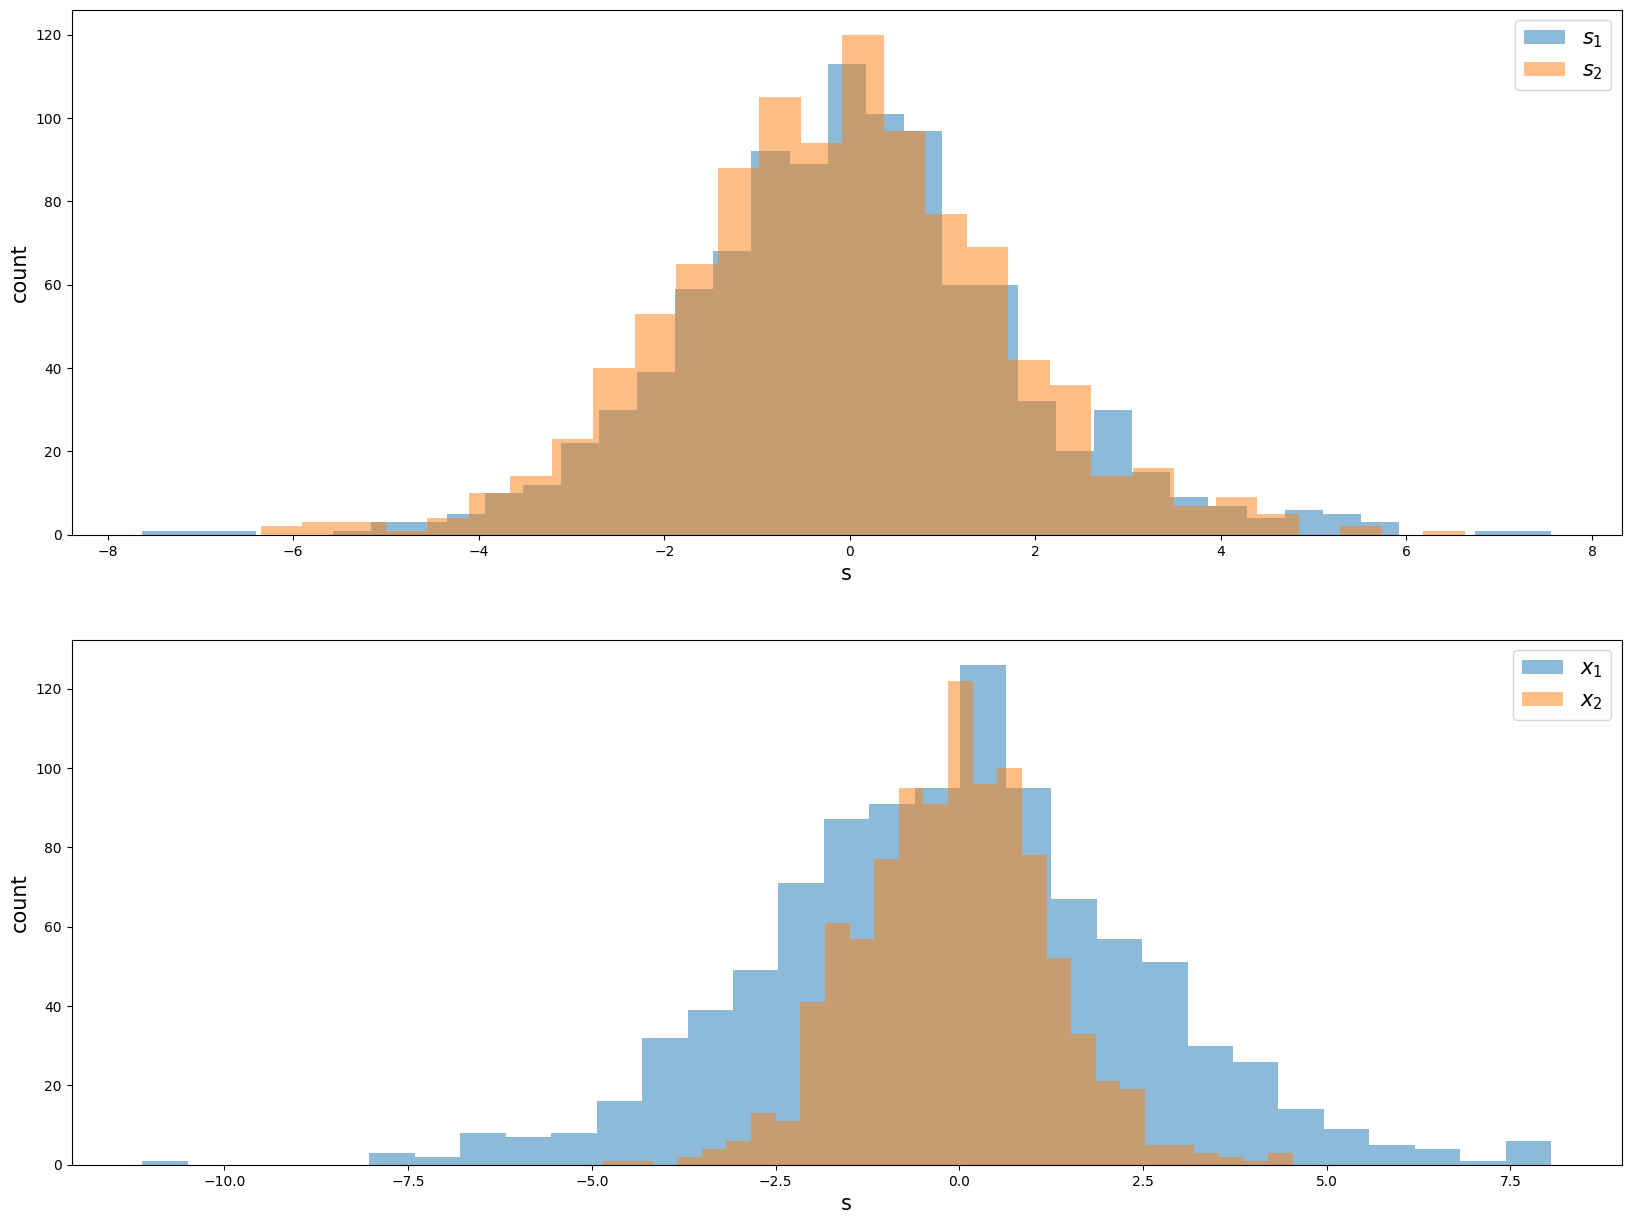

In [ ]:
# Number of sources and observations
NSOURCES=2
NOBS=1000

# Mixing matrix configuration
A = np.array([
    [1, 1],
    [-0.5, 0.5]
])

# Ideal separation matrix
B = np.linalg.inv(A)

# Get source realization
s = StandardLogisticSource(
    use_jax=True
).get_realization(
    nsources=NSOURCES,
    nobs=NOBS,
    seed=100
)
# Get mixtures
x = A@s

# Plot
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1, figsize=(20,15)
)

# Ax1
ax1.hist(
    s[0,:],
    bins='fd',
    label='$s_{1}$',
    alpha=0.5
)
ax1.hist(
    s[1,:],
    bins='fd',
    label='$s_{2}$',
    alpha=0.5
)
ax1.legend(fontsize=15)
ax1.set_xlabel(
    's',
    fontsize=15
)
ax1.set_ylabel(
    'count',
    fontsize=15
)

# Ax2
ax2.hist(
    x[0,:],
    bins='fd',
    label='$x_{1}$',
    alpha=0.5
)
ax2.hist(
    x[1,:],
    bins='fd',
    label='$x_{2}$',
    alpha=0.5
)
ax2.legend(fontsize=15)
ax2.set_xlabel(
    's',
    fontsize=15
)
ax2.set_ylabel(
    'count',
    fontsize=15
)

In [7]:
N_SAMPLES=20000
EXPLORATION_VAR = 1E-3
PARALLEL_CHAINS=10
R_HAT_THRESH=1.01
R_HAT_MINIMUM_BURN_IN=5000
R_HAT_EVALUATION_STEP=100
R_HAT_PERSISTANCE=10
MAX_IT=20000

# Source model pdf
source_pdf = StandardLogisticSource(use_jax=True).get()

# Prior pdf
prior_pdf = ExponentialPrior(
    center=B,
    std=0.1,
    use_jax=True
).get()

# Initial conditions
initial_condition = jnp.asarray([
    np.add(
        np.random.uniform(
            low=-0.5,
            high=0.5,
            size=B.shape
        ),
        B
    ) for c in range(PARALLEL_CHAINS)
])

In [8]:
mmse = MMSEBarkerMHEstimator(
    n_samples=N_SAMPLES,
    source_pdf_fn=source_pdf,
    prior_pdf_fn=prior_pdf,
    exploration_var=EXPLORATION_VAR,
    parallel_chains=PARALLEL_CHAINS,
    max_it=MAX_IT,
    R_hat_thresh=R_HAT_THRESH,
    R_hat_evaluation_step=R_HAT_EVALUATION_STEP,
    R_hat_persistance=R_HAT_PERSISTANCE,
    R_hat_minimum_burn_in=R_HAT_MINIMUM_BURN_IN,
    auto_adjust_exploration_var=True,
    
)

samples, diagnostics, logs = mmse.fit(
    x=x,
    initial_condition=initial_condition
)
print('#'*100)
print('B estimado via MMSE:\n{}'.format(mmse.mcmc_results['B_est']))
print('#'*100)

/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_8878/2348617134.py:327: UserWarning: There are not enough devices to run parallel chains: expected 10 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(10)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(


####################################################################################################
B estimado via MMSE:
[[ 0.49393412 -1.00866137]
 [ 0.51085333  0.99956832]]
####################################################################################################


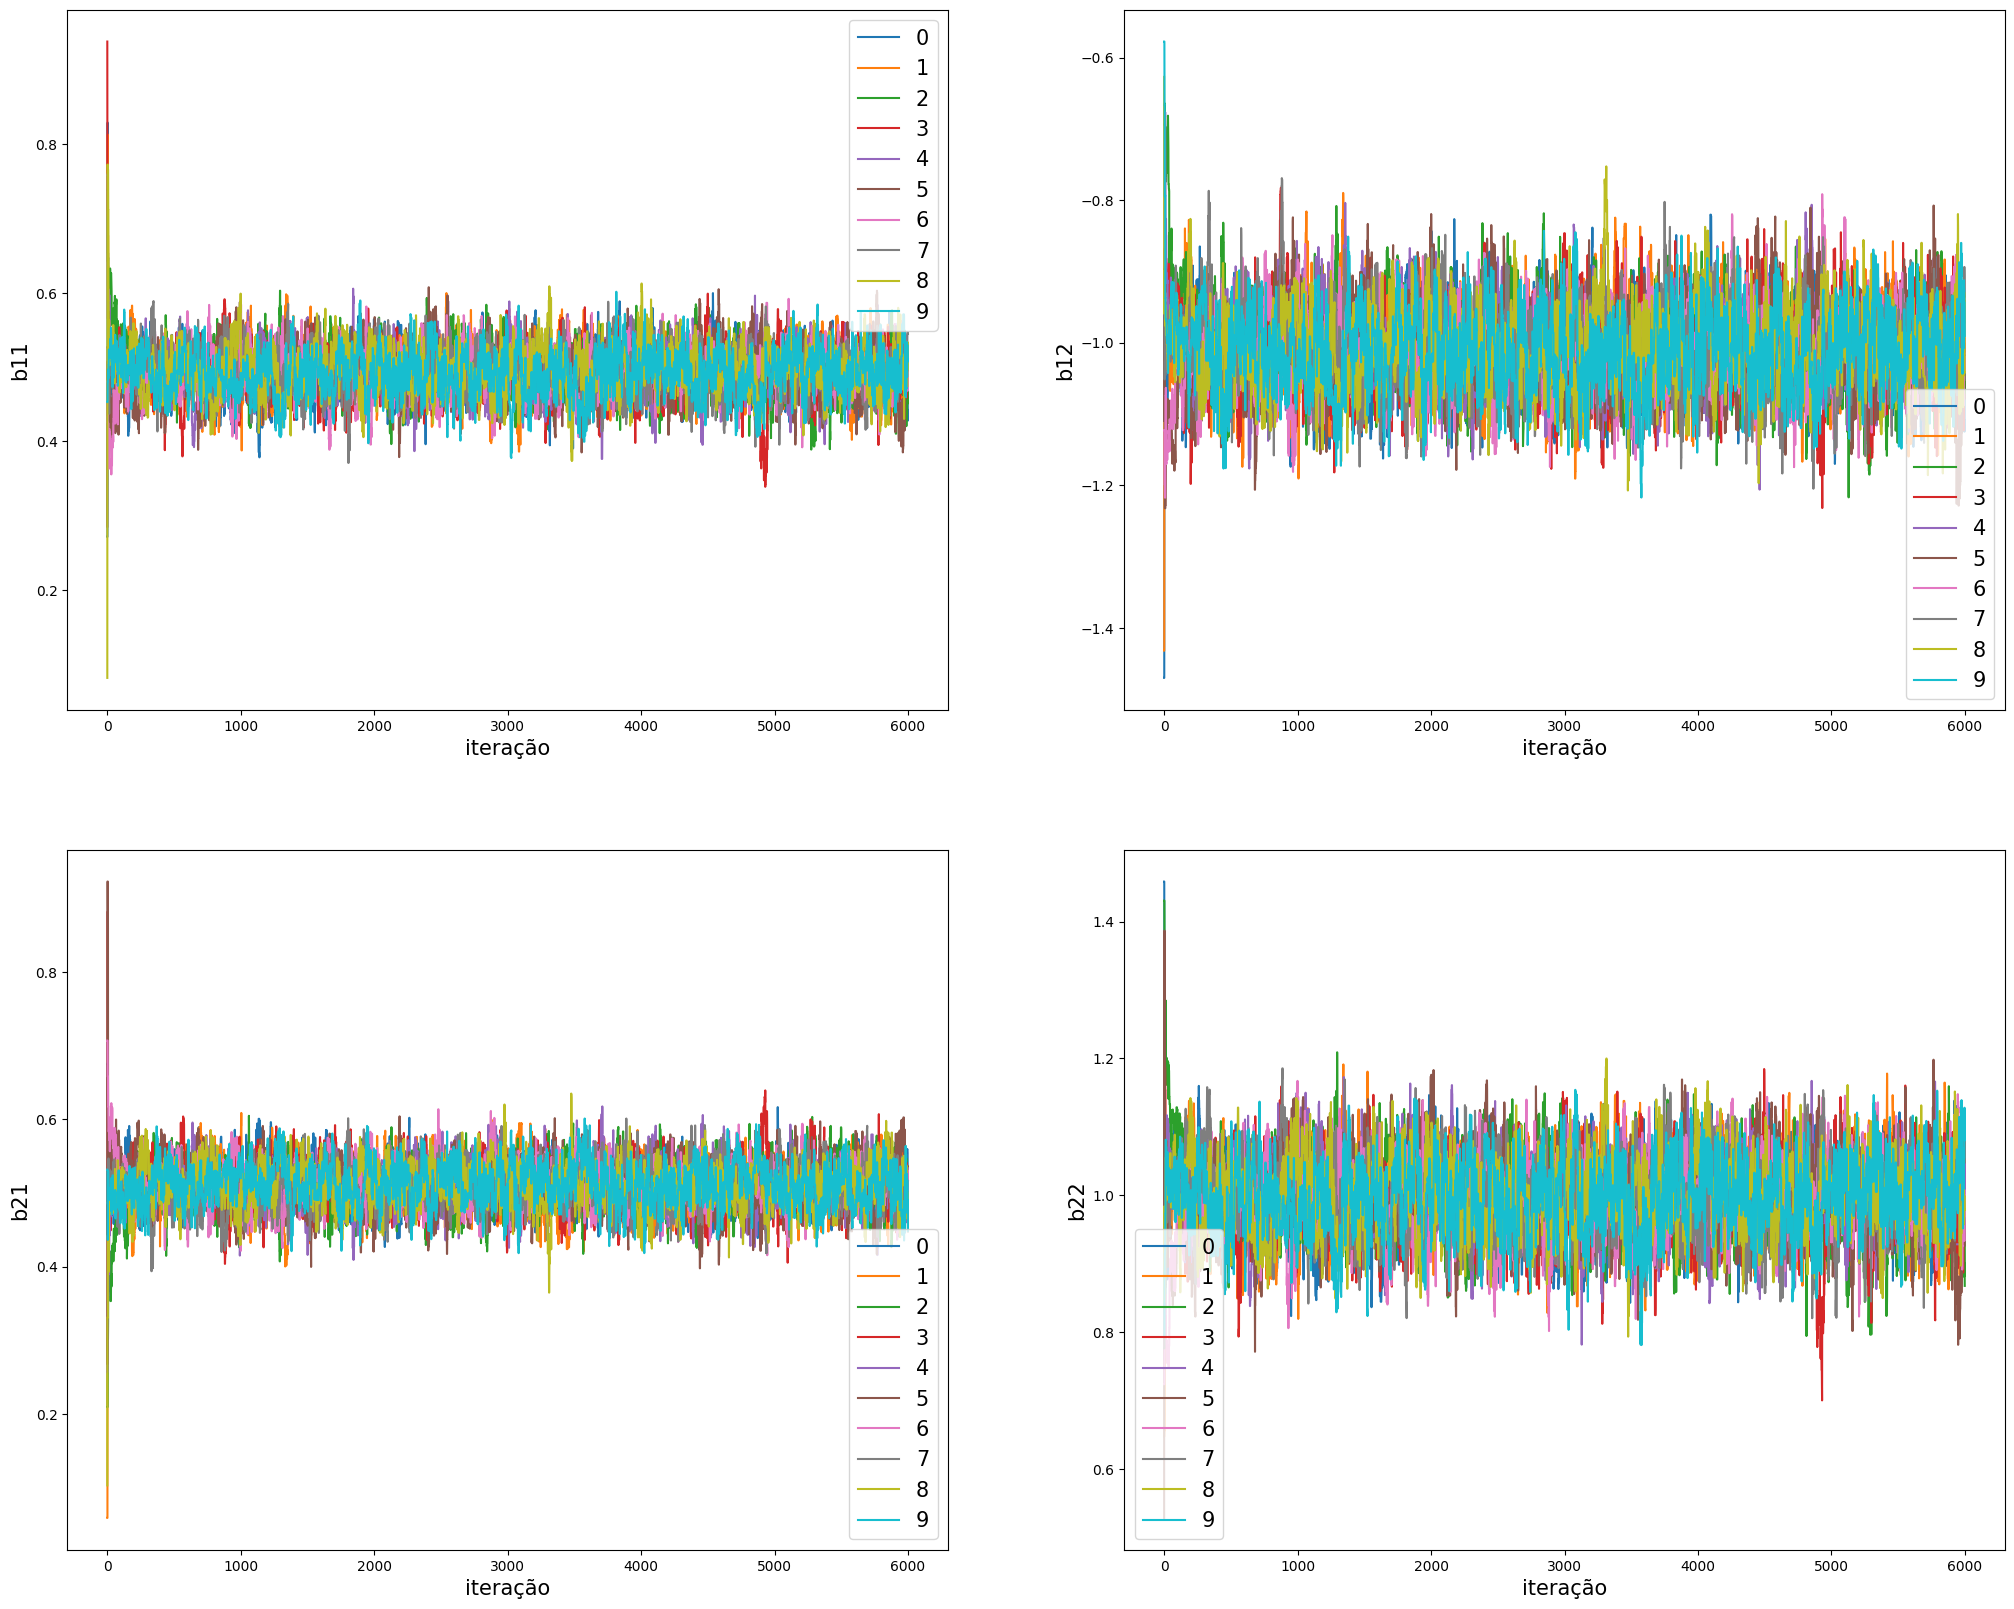

In [9]:
# Plot chain evolutions
fig, axs = plt.subplots(
    nrows=2, ncols=2,
    figsize=(25,20)
)

for i,j in np.ndindex(B.shape):
    for c in range(PARALLEL_CHAINS):
        axs[i,j].plot(
            samples[c][:,i,j],
            label=c
        )
    axs[i,j].legend(
        fontsize=15
    )
    axs[i,j].set_xlabel(
        'iteração',
        fontsize=15
    )
    axs[i,j].set_ylabel(
        'b{}{}'.format(
            i+1,
            j+1
        ),
        fontsize=15
    )

<>:44: SyntaxWarning: invalid escape sequence '\h'
<>:44: SyntaxWarning: invalid escape sequence '\h'
/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_8878/2285946103.py:44: SyntaxWarning: invalid escape sequence '\h'
  '$\hat{R}$',


,iteration,r_hat_b_11,ess_b_11,r_hat_b_12,ess_b_12,r_hat_b_21,ess_b_21,r_hat_b_22,ess_b_22
0,5100,1.005236,738.833745,1.006207,746.765987,1.004451,726.789127,1.005291,753.071049
1,5200,1.004236,737.245340,1.005894,732.095041,1.004202,728.282388,1.004663,744.489995
2,5300,1.003577,778.698327,1.005548,788.182186,1.004030,770.033124,1.005001,760.541331
3,5400,1.003532,757.510462,1.004478,776.403593,1.004038,758.975338,1.004768,742.503167
4,5500,1.004492,762.465242,1.005777,767.111002,1.005230,765.635742,1.006046,737.868123
5,5600,1.003080,803.780454,1.005071,826.638137,1.004773,809.087862,1.005288,779.698893
6,5700,1.002905,777.140845,1.004359,788.935603,1.004089,806.102954,1.004091,765.113766
7,5800,1.003502,770.462166,1.005113,773.752570,1.004604,804.109164,1.004573,749.615260
8,5900,1.002219,774.717838,1.003209,784.828933,1.002517,810.548224,1.002919,763.770119
9,6000,1.002910,764.311949,1.003610,775.944288,1.002502,802.398852,1.004406,764.271992


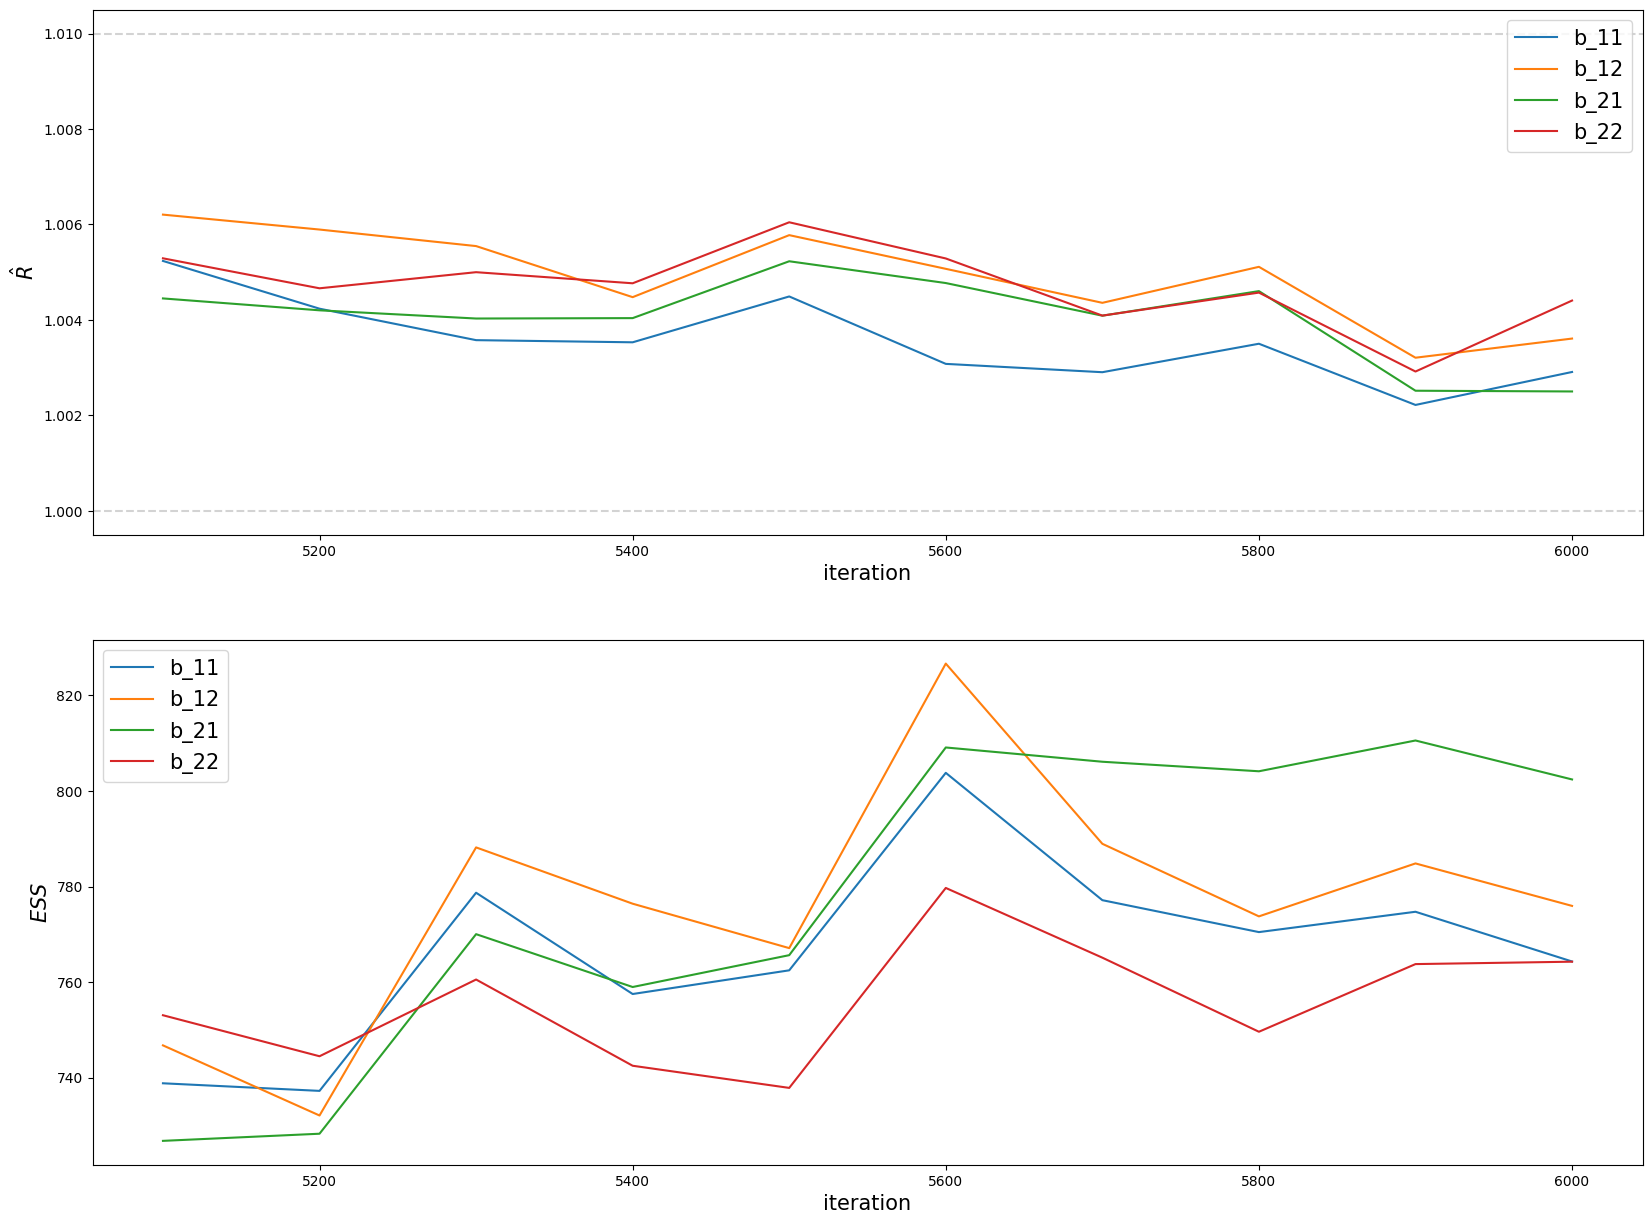

In [10]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(20,15)
)

# Get R-hat columns
R_hat_cols = [c for c in diagnostics.columns if 'r_hat' in c]

# Get ESS columns
ESS_cols = [c for c in diagnostics.columns if 'ess' in c]

for c in R_hat_cols:
    ax1.plot(
        diagnostics.iteration,
        diagnostics[c],
        label=c[-4:]
    )

for c in ESS_cols:
    ax2.plot(
        diagnostics.iteration,
        diagnostics[c],
        label=c[-4:]
    )

ax1.axhline(
    1,
    c='lightgray',
    linestyle='--'
)

ax1.axhline(
    R_HAT_THRESH,
    c='lightgray',
    linestyle='--'
)

ax1.set_xlabel(
    'iteration',
    fontsize=15
)

ax1.set_ylabel(
    '$\hat{R}$',
    fontsize=15
)

l1=ax1.legend(
    fontsize=15
)

ax2.set_xlabel(
    'iteration',
    fontsize=15
)

ax2.set_ylabel(
    '$ESS$',
    fontsize=15
)

l2=ax2.legend(
    fontsize=15
)

diagnostics

100%|██████████| 1198/1198 [00:00<00:00, 5479.30it/s]


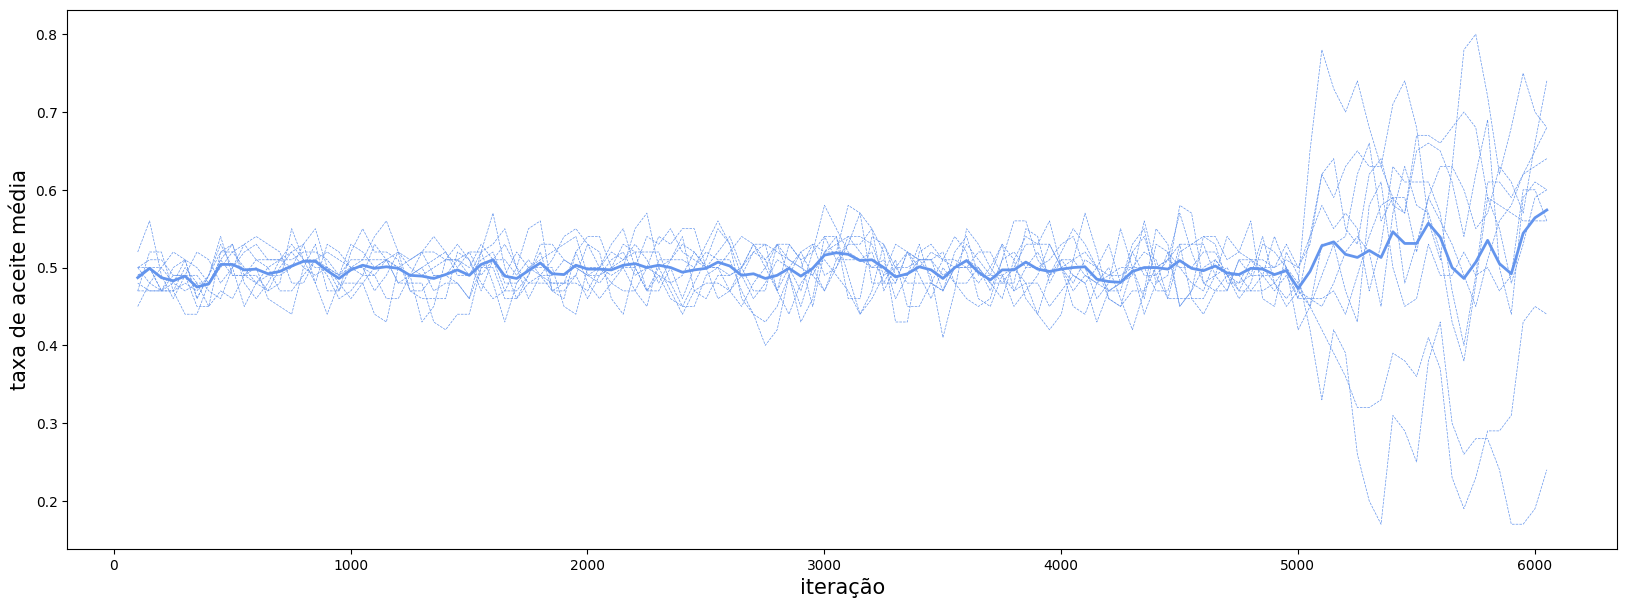

In [60]:
WDW_SIZE=100
STEP_SIZE=50
avg_acceptances = {c: [] for c in logs.chain.unique()}
evaluated_its=range(WDW_SIZE+1, logs.shape[0]+1, STEP_SIZE)
for c, group in logs.groupby(
        by=['chain']
    ):
    c=c[0]
    for i in tqdm(evaluated_its):
        mean_accept = group[
            (group.inside_iteration<i)&
            (group.inside_iteration>=i-WDW_SIZE)
        ].save_new_sample.astype(float).mean()
        avg_acceptances[c].append(mean_accept)

overall_acceptance = np.array([
    logs[
        (logs.inside_iteration<i)&
        (logs.inside_iteration>=i-WDW_SIZE)
    ].save_new_sample.astype(float).mean() for i in evaluated_its
])

fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(20,7)
)

ax.set_xlabel(
    'iteração',
    fontsize=15
)
ax.set_ylabel(
    'taxa de aceite média',
    fontsize=15
)

for c, alphas in avg_acceptances.items():
    ax.plot(
        evaluated_its,
        avg_acceptances[c],
        linestyle = '--',
        linewidth=.5,
        color='cornflowerblue',
        label=c
    )

ax.plot(
    evaluated_its,
    overall_acceptance,
    linewidth=2,
    color='cornflowerblue'
)



In [58]:
np.array(
    [
        avg_acceptances[c] for c in avg_acceptances.keys()
    ]
)[:,1100]

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])

In [ ]:
diagnostics[
    diagnosticsinside_interation>WDW_SIZE
]

AttributeError: 'DataFrame' object has no attribute 'inside_interation'

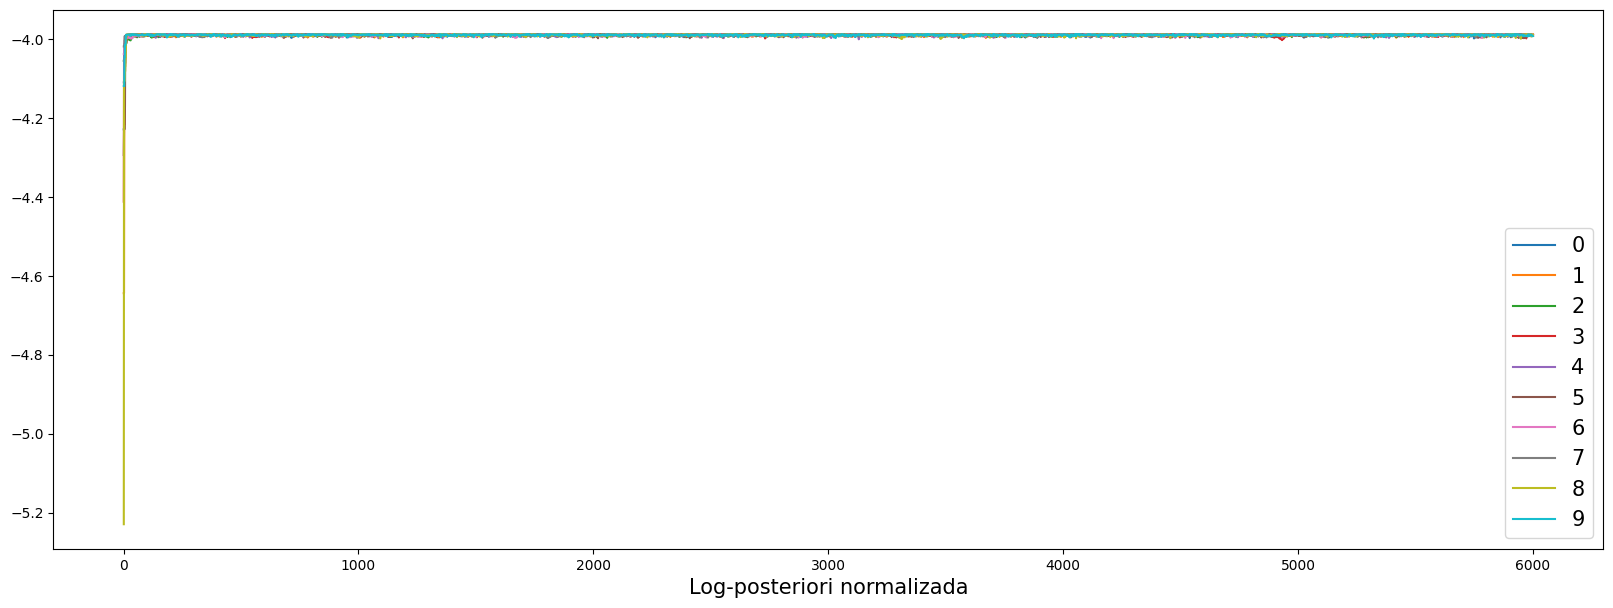

In [11]:
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(20,7)
)

for c, c_group in logs.groupby(by='chain'):
    ax.plot(
        c_group.iteration,
        c_group.log_posterior,
        label=c
    )
ax.set_xlabel(
    'iteration',
    fontsize=15
)
ax.set_xlabel(
    'Log-posteriori normalizada',
    fontsize=15
)
ax.legend(
    fontsize=15
)

# 3. Comparar com MH Simples

In [12]:
samples_barker = copy.deepcopy(samples)
diagnostics_barker = copy.deepcopy(diagnostics)
logs_barker = copy.deepcopy(logs)

# Source model pdf
source_pdf_MH = StandardLogisticSource(use_jax=False).get()

# Prior pdf
prior_pdf_MH = ExponentialPrior(
    center=B,
    std=0.1,
    use_jax=False
).get()

In [13]:
mmse_MH = MMSEMetropolisHastingsEstimator(
    n_samples=N_SAMPLES,
    source_pdf_fn=source_pdf_MH,
    prior_pdf_fn=prior_pdf_MH,
    exploration_var=EXPLORATION_VAR,
    parallel_chains=PARALLEL_CHAINS,
    max_it=MAX_IT,
    R_hat_thresh=R_HAT_THRESH,
    R_hat_evaluation_step=R_HAT_EVALUATION_STEP,
    R_hat_persistance=R_HAT_PERSISTANCE,
    R_hat_minimum_burn_in=R_HAT_MINIMUM_BURN_IN,
)

samples_MH, diagnostics_MH, logs_MH = mmse_MH.fit(
    x=x,
    initial_condition=initial_condition
)
print('#'*100)
print('B estimado via MMSE:\n{}'.format(mmse_MH.mcmc_results['B_est']))
print('#'*100)

####################################################################################################
B estimado via MMSE:
[[ 0.49297851 -1.01094507]
 [ 0.5117078   0.9964188 ]]
####################################################################################################


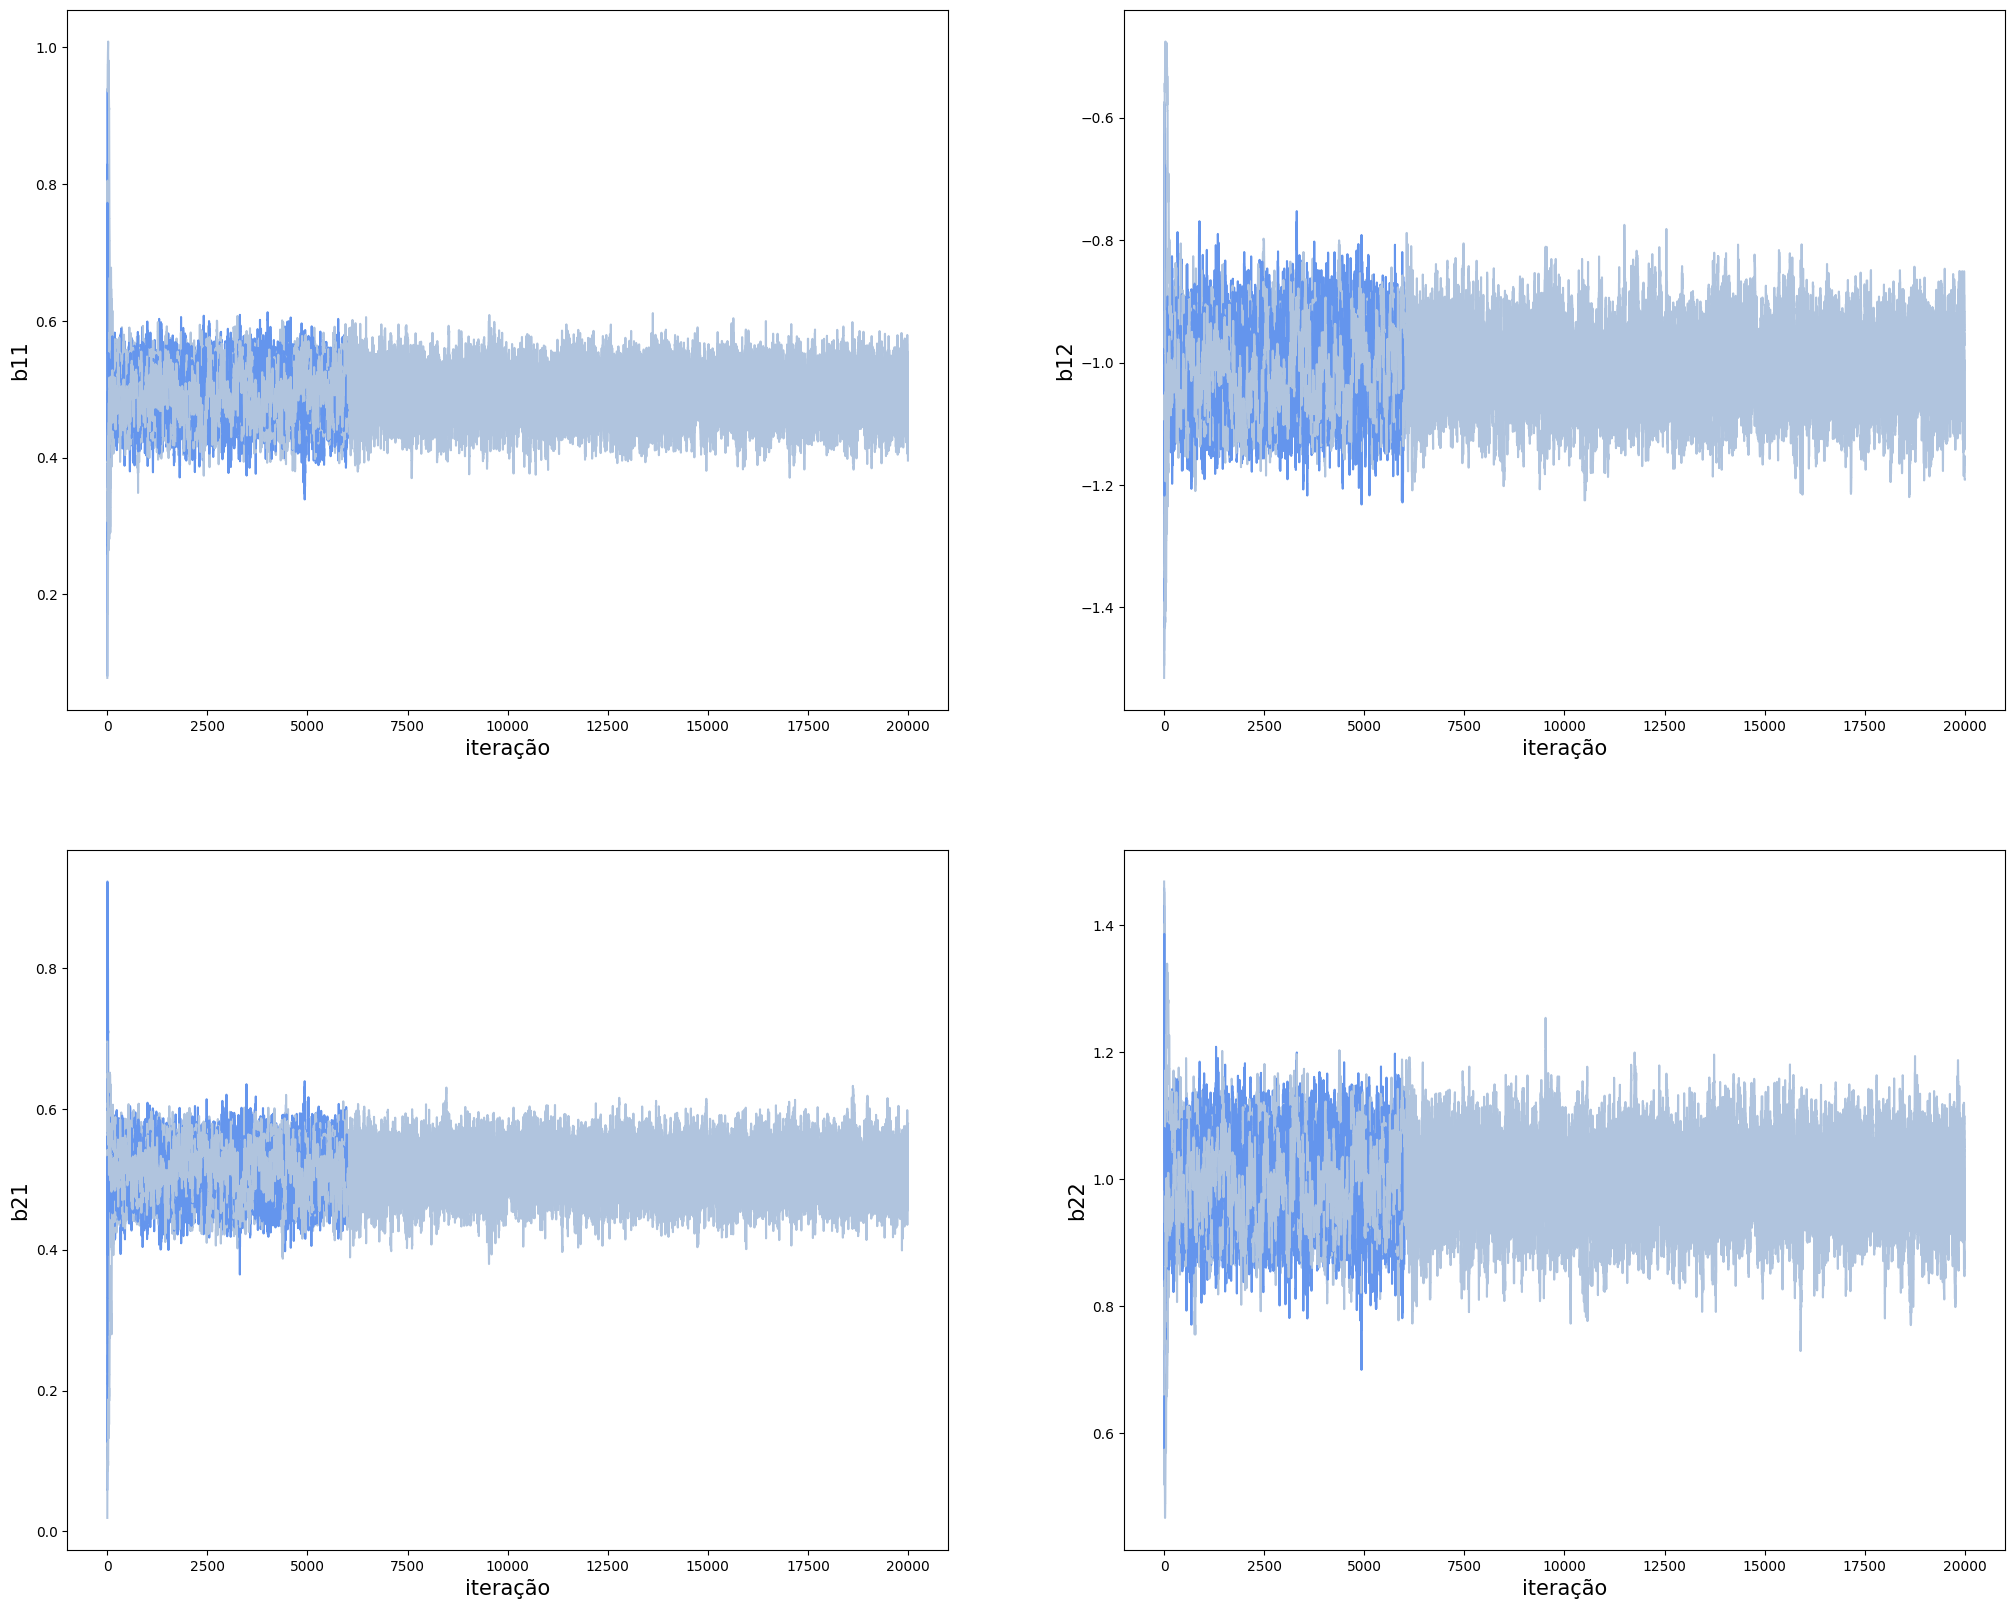

In [14]:
# Plot chain evolutions
fig, axs = plt.subplots(
    nrows=2, ncols=2,
    figsize=(25,20)
)

for i,j in np.ndindex(B.shape):
    for c in range(PARALLEL_CHAINS):
        axs[i,j].plot(
            samples_barker[c][:,i,j],
            # label='BarkerMH',
            color='cornflowerblue'
        )
        axs[i,j].plot(
            samples_MH[c][:,i,j],
            # label='MH',
            color='lightsteelblue'
        )
    # axs[i,j].legend(
    #     fontsize=15
    # )
    axs[i,j].set_xlabel(
        'iteração',
        fontsize=15
    )
    axs[i,j].set_ylabel(
        'b{}{}'.format(
            i+1,
            j+1
        ),
        fontsize=15
    )

<>:44: SyntaxWarning: invalid escape sequence '\h'
<>:44: SyntaxWarning: invalid escape sequence '\h'
/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_8878/884876028.py:44: SyntaxWarning: invalid escape sequence '\h'
  '$\hat{R}$',


,iteration,r_hat_b_11,ess_b_11,r_hat_b_12,ess_b_12,r_hat_b_21,ess_b_21,r_hat_b_22,ess_b_22
0,7000,1.012548,296.225588,1.017730,244.748332,1.018020,295.185796,1.011977,239.464955
1,7100,1.014514,293.106211,1.022097,242.565511,1.019260,305.458638,1.015911,227.088868
2,7200,1.018135,281.440874,1.025771,231.491125,1.024306,291.430102,1.018098,218.096664
3,7300,1.019897,274.337001,1.027585,220.290144,1.024828,269.073601,1.021717,204.224444
4,7400,1.019630,272.410287,1.024631,226.442942,1.022246,279.866079,1.021720,207.749091
...,...,...,...,...,...,...,...,...,...
126,19600,1.008321,386.295408,1.014728,313.517874,1.009613,439.611618,1.020989,285.721380
127,19700,1.007907,393.277681,1.015619,319.771034,1.009936,444.998464,1.021716,292.669100
128,19800,1.011061,385.737198,1.015280,314.200206,1.012069,431.882354,1.022034,287.549658
129,19900,1.015255,366.948318,1.018580,312.164686,1.016063,418.027155,1.027614,259.061005


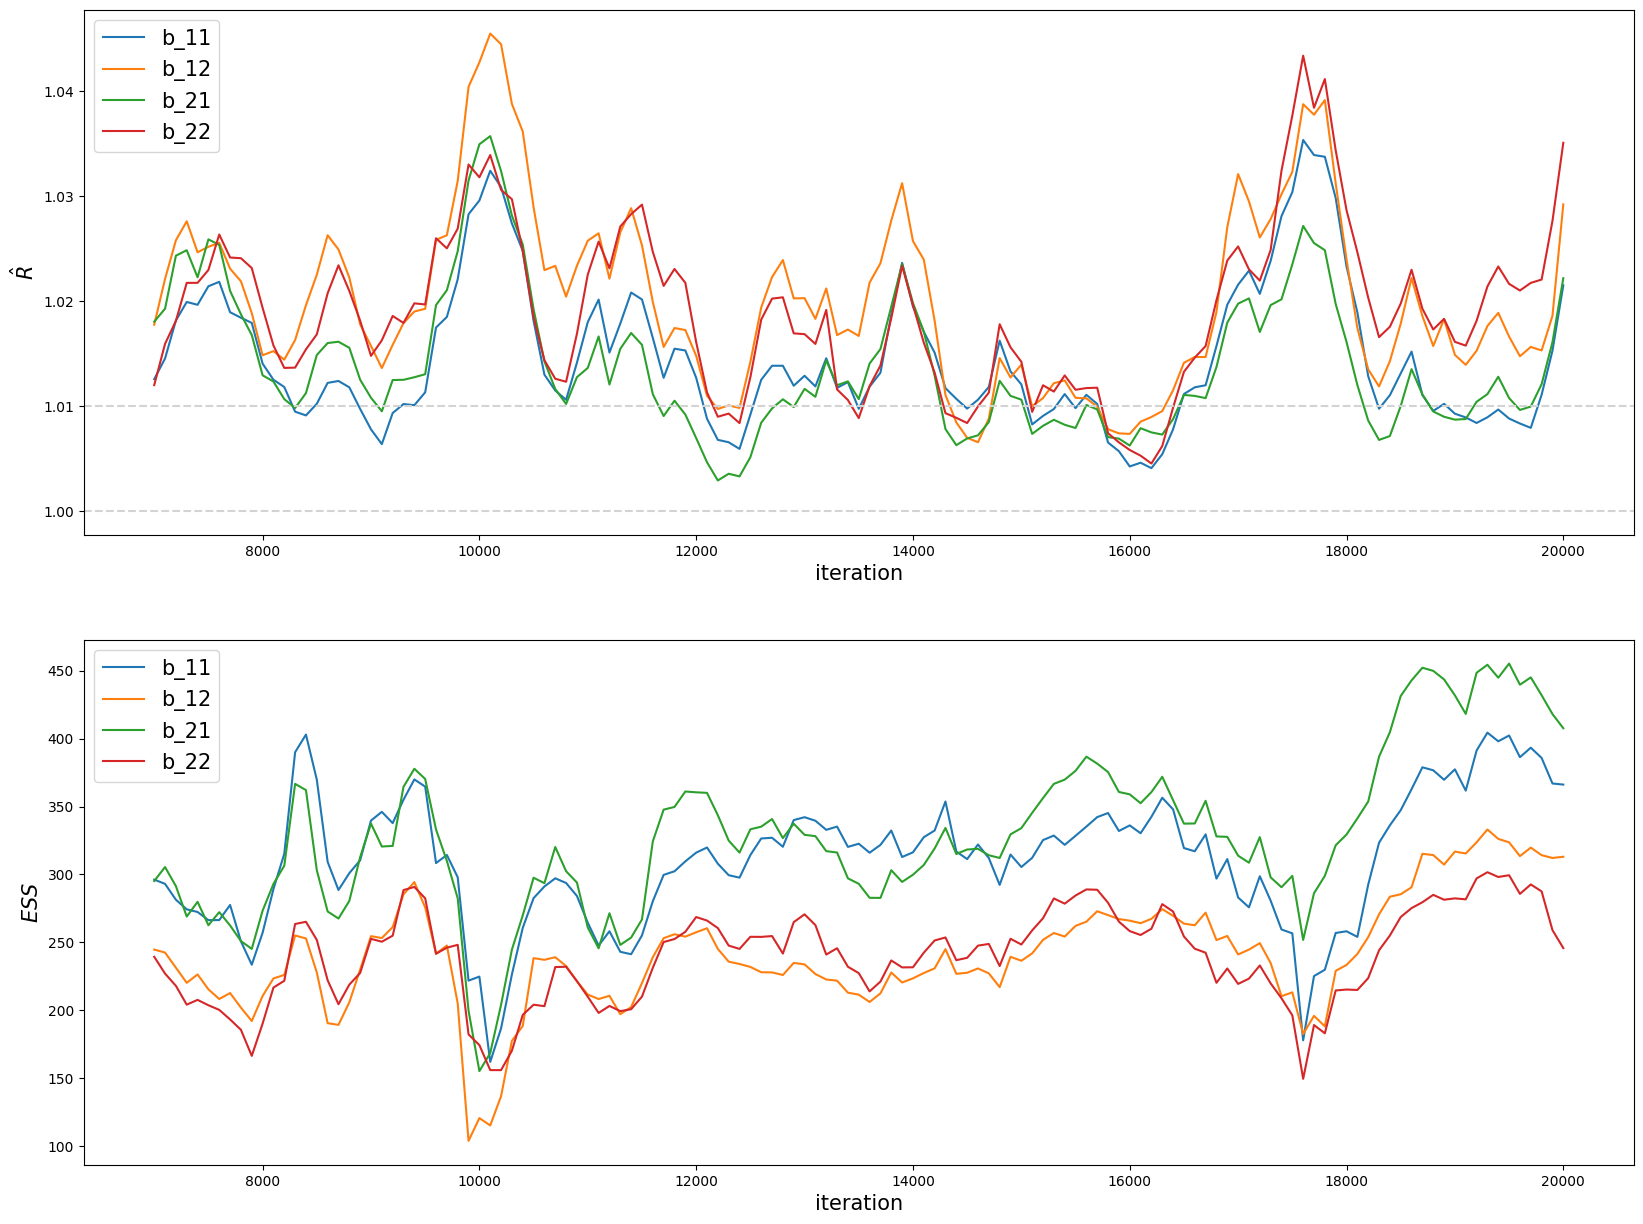

In [15]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(20,15)
)

# Get R-hat columns
R_hat_cols = [c for c in diagnostics_MH.columns if 'r_hat' in c]

# Get ESS columns
ESS_cols = [c for c in diagnostics_MH.columns if 'ess' in c]

for c in R_hat_cols:
    ax1.plot(
        diagnostics_MH.iteration,
        diagnostics_MH[c],
        label=c[-4:]
    )

for c in ESS_cols:
    ax2.plot(
        diagnostics_MH.iteration,
        diagnostics_MH[c],
        label=c[-4:]
    )

ax1.axhline(
    1,
    c='lightgray',
    linestyle='--'
)

ax1.axhline(
    R_HAT_THRESH,
    c='lightgray',
    linestyle='--'
)

ax1.set_xlabel(
    'iteration',
    fontsize=15
)

ax1.set_ylabel(
    '$\hat{R}$',
    fontsize=15
)

l1=ax1.legend(
    fontsize=15
)

ax2.set_xlabel(
    'iteration',
    fontsize=15
)

ax2.set_ylabel(
    '$ESS$',
    fontsize=15
)

l2=ax2.legend(
    fontsize=15
)

diagnostics_MH

100%|██████████| 3998/3998 [00:00<00:00, 5843.12it/s]


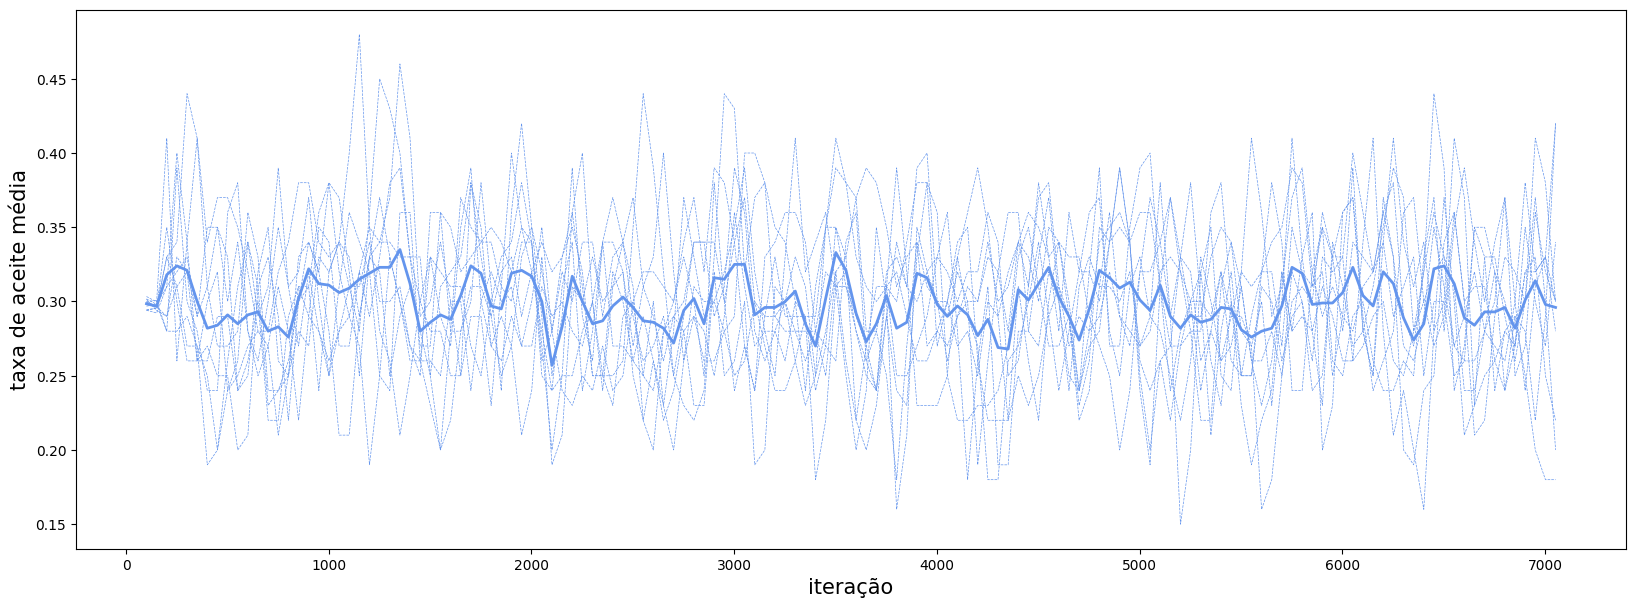

In [61]:
WDW_SIZE=100
STEP_SIZE=50
avg_acceptances = {c: [] for c in logs_MH.chain.unique()}
evaluated_its=range(WDW_SIZE+1, logs_MH.shape[0]+1, STEP_SIZE)
for c, group in logs_MH.groupby(
        by=['chain']
    ):
    c=c[0]
    for i in tqdm(evaluated_its):
        mean_accept = group[
            (group.inside_iteration<i)&
            (group.inside_iteration>=i-WDW_SIZE)
        ].save_new_sample.astype(float).mean()
        avg_acceptances[c].append(mean_accept)

overall_acceptance = np.array([
    logs_MH[
        (logs_MH.inside_iteration<i)&
        (logs_MH.inside_iteration>=i-WDW_SIZE)
    ].save_new_sample.astype(float).mean() for i in evaluated_its
])

fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(20,7)
)

ax.set_xlabel(
    'iteração',
    fontsize=15
)
ax.set_ylabel(
    'taxa de aceite média',
    fontsize=15
)

for c, alphas in avg_acceptances.items():
    ax.plot(
        evaluated_its,
        avg_acceptances[c],
        linestyle = '--',
        linewidth=.5,
        color='cornflowerblue',
        label=c
    )

ax.plot(
    evaluated_its,
    overall_acceptance,
    linewidth=2,
    color='cornflowerblue'
)

